# Satellite Imagery Analysis — INSAT-3D Visible Channel (Pune, 2023)

This notebook explores the INSAT-3D satellite imagery aligned to the 500 kW PV plant site in Pune.  
Each image is a 64×64 pixel visible-channel patch, one per hour, covering the full year 2023 (8760 patches).  
The patches are used as the image modality in the multi-modal forecasting model.

In [1]:
# ── Setup ────────────────────────────────────────────────────────────────────
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from PIL import Image
import os

DATA = Path('../solar_forecast/data')
FIG  = Path('figures')
FIG.mkdir(exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 130,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

MONTHS     = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
SEASON_CLR = {
    'Winter':       '#4472C4',
    'Pre-Monsoon':  '#ED7D31',
    'Monsoon':      '#70AD47',
    'Post-Monsoon': '#9E480E',
}

def month_to_season(m):
    if m in [12, 1, 2]:        return 'Winter'
    elif m in [3, 4, 5]:       return 'Pre-Monsoon'
    elif m in [6, 7, 8, 9]:    return 'Monsoon'
    else:                      return 'Post-Monsoon'

print('Setup complete.')

Setup complete.


## 1. Load Satellite Patches

In [2]:
npz = np.load(DATA /'satellite_patches.npz')
images = npz['images']   # (8760, 64, 64, 3)

print(f'Shape  : {images.shape}')
print(f'Dtype  : {images.dtype}')
print(f'Min    : {images.min():.4f}')
print(f'Max    : {images.max():.4f}')
print(f'Mean   : {images.mean():.4f}')

# Load SCADA timestamps
scada = pd.read_csv(DATA / 'pune_500kw_hourly.csv', parse_dates=['timestamp'])
timestamps = scada['timestamp']
assert len(timestamps) == len(images), 'Timestamp count mismatch!'
print(f'\nAligned to {len(timestamps)} hourly timestamps.')

Shape  : (8760, 64, 64, 3)
Dtype  : uint8
Min    : 0.0000
Max    : 224.0000
Mean   : 33.2915

Aligned to 8760 hourly timestamps.


In [4]:
# Compute per-patch brightness (mean pixel value)
brightness = images.mean(axis=(1, 2, 3))   # shape: (8760,)

df = scada[['timestamp', 'power_kw', 'ghi', 'cloud_cover', 'humidity']].copy()
df['brightness'] = brightness
df['month']      = df['timestamp'].dt.month
df['hour']       = df['timestamp'].dt.hour
df['season']     = df['month'].map(month_to_season)

print('brightness stats:')
print(pd.Series(brightness).describe().round(4))

brightness stats:
count    8760.0000
mean       33.2915
std        42.1075
min         0.0000
25%         0.0000
50%         0.0000
75%        71.4137
max       163.3766
dtype: float64


## 2. Brightness Validation

### 2a. Brightness vs Cloud Cover (daytime)

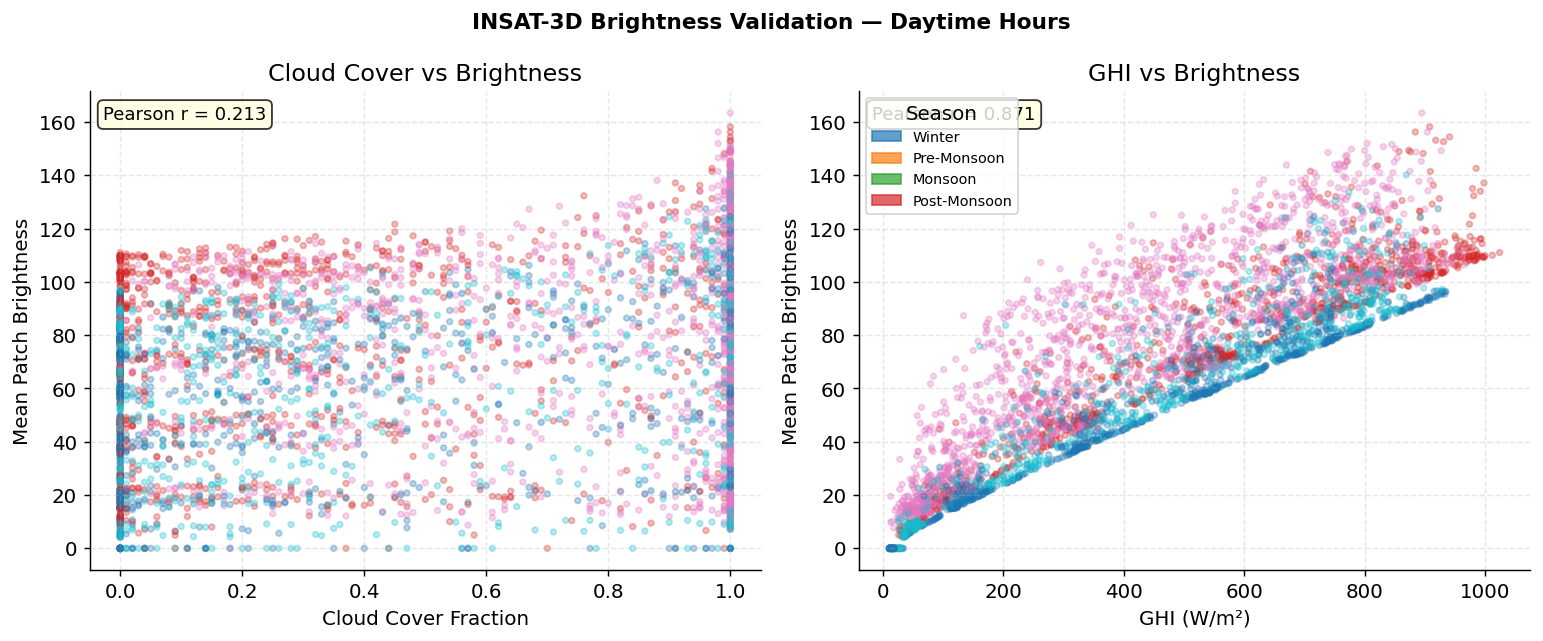

Cloud cover vs brightness : r = 0.213
GHI vs brightness         : r = 0.871
Saved: satellite_brightness_validation.png


In [5]:
from scipy import stats

day = df[(df['ghi'] > 10) & (df['hour'].between(6, 18))].copy()

r_cc, _ = stats.pearsonr(day['cloud_cover'], day['brightness'])
r_gh, _ = stats.pearsonr(day['ghi'],         day['brightness'])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('INSAT-3D Brightness Validation — Daytime Hours', fontsize=12, fontweight='bold')

season_order = list(SEASON_CLR.keys())
day['season_idx'] = day['season'].map({s: i for i, s in enumerate(season_order)})

# Cloud cover vs brightness
axes[0].scatter(day['cloud_cover'], day['brightness'],
                c=day['season_idx'], cmap='tab10',
                alpha=0.30, s=10, rasterized=True)
axes[0].set_xlabel('Cloud Cover Fraction')
axes[0].set_ylabel('Mean Patch Brightness')
axes[0].set_title('Cloud Cover vs Brightness')
axes[0].text(0.02, 0.97, f'Pearson r = {r_cc:.3f}',
             transform=axes[0].transAxes, va='top', fontsize=10,
             bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))
axes[0].grid(linestyle='--', alpha=0.3)

# GHI vs brightness
axes[1].scatter(day['ghi'], day['brightness'],
                c=day['season_idx'], cmap='tab10',
                alpha=0.30, s=10, rasterized=True)
axes[1].set_xlabel('GHI (W/m²)')
axes[1].set_ylabel('Mean Patch Brightness')
axes[1].set_title('GHI vs Brightness')
axes[1].text(0.02, 0.97, f'Pearson r = {r_gh:.3f}',
             transform=axes[1].transAxes, va='top', fontsize=10,
             bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))
axes[1].grid(linestyle='--', alpha=0.3)

handles = [mpatches.Patch(color=plt.cm.tab10(i / 9), alpha=0.7, label=s)
           for i, s in enumerate(season_order)]
axes[1].legend(handles=handles, fontsize=8, title='Season')

plt.tight_layout()
fig.savefig(FIG / 'satellite_brightness_validation.png', bbox_inches='tight')
plt.show()
print(f'Cloud cover vs brightness : r = {r_cc:.3f}')
print(f'GHI vs brightness         : r = {r_gh:.3f}')
print('Saved: satellite_brightness_validation.png')

## 3. Monthly Brightness Bar Chart

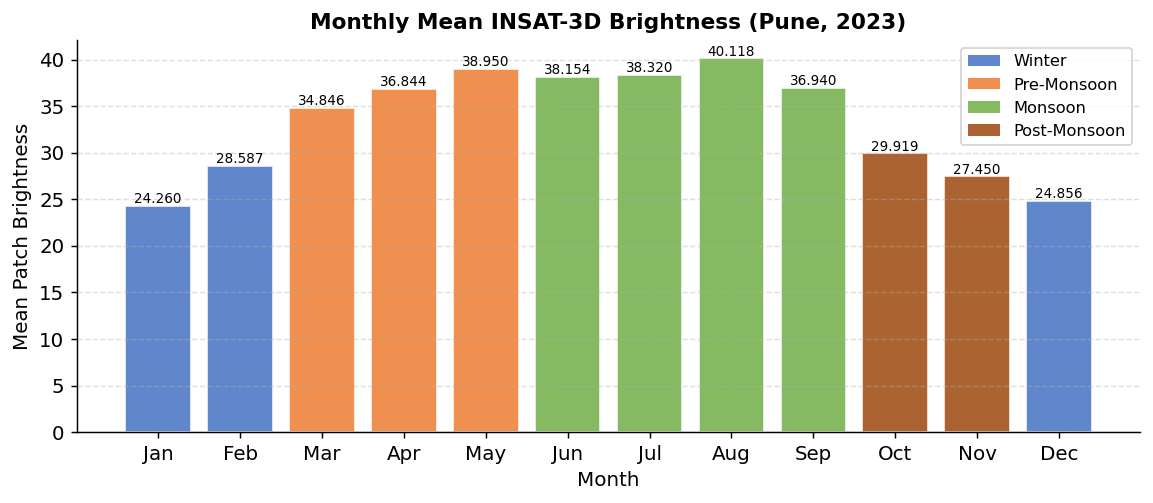

Saved: satellite_monthly_brightness.png


In [6]:
monthly_bright = df.groupby('month')['brightness'].mean()
bar_colors = [SEASON_CLR[month_to_season(m)] for m in range(1, 13)]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(range(1, 13), monthly_bright.values,
              color=bar_colors, alpha=0.85, edgecolor='white')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(MONTHS)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Mean Patch Brightness', fontsize=11)
ax.set_title('Monthly Mean INSAT-3D Brightness (Pune, 2023)', fontsize=12, fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.4)

for bar, val in zip(bars, monthly_bright.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.3f}', ha='center', va='bottom', fontsize=7.5)

handles = [mpatches.Patch(facecolor=c, alpha=0.85, label=s) for s, c in SEASON_CLR.items()]
ax.legend(handles=handles, fontsize=9)

plt.tight_layout()
fig.savefig(FIG / 'satellite_monthly_brightness.png', bbox_inches='tight')
plt.show()
print('Saved: satellite_monthly_brightness.png')

## 4. Sample Patch Grid — 4 Seasons × 5 Cloud Cover Bins

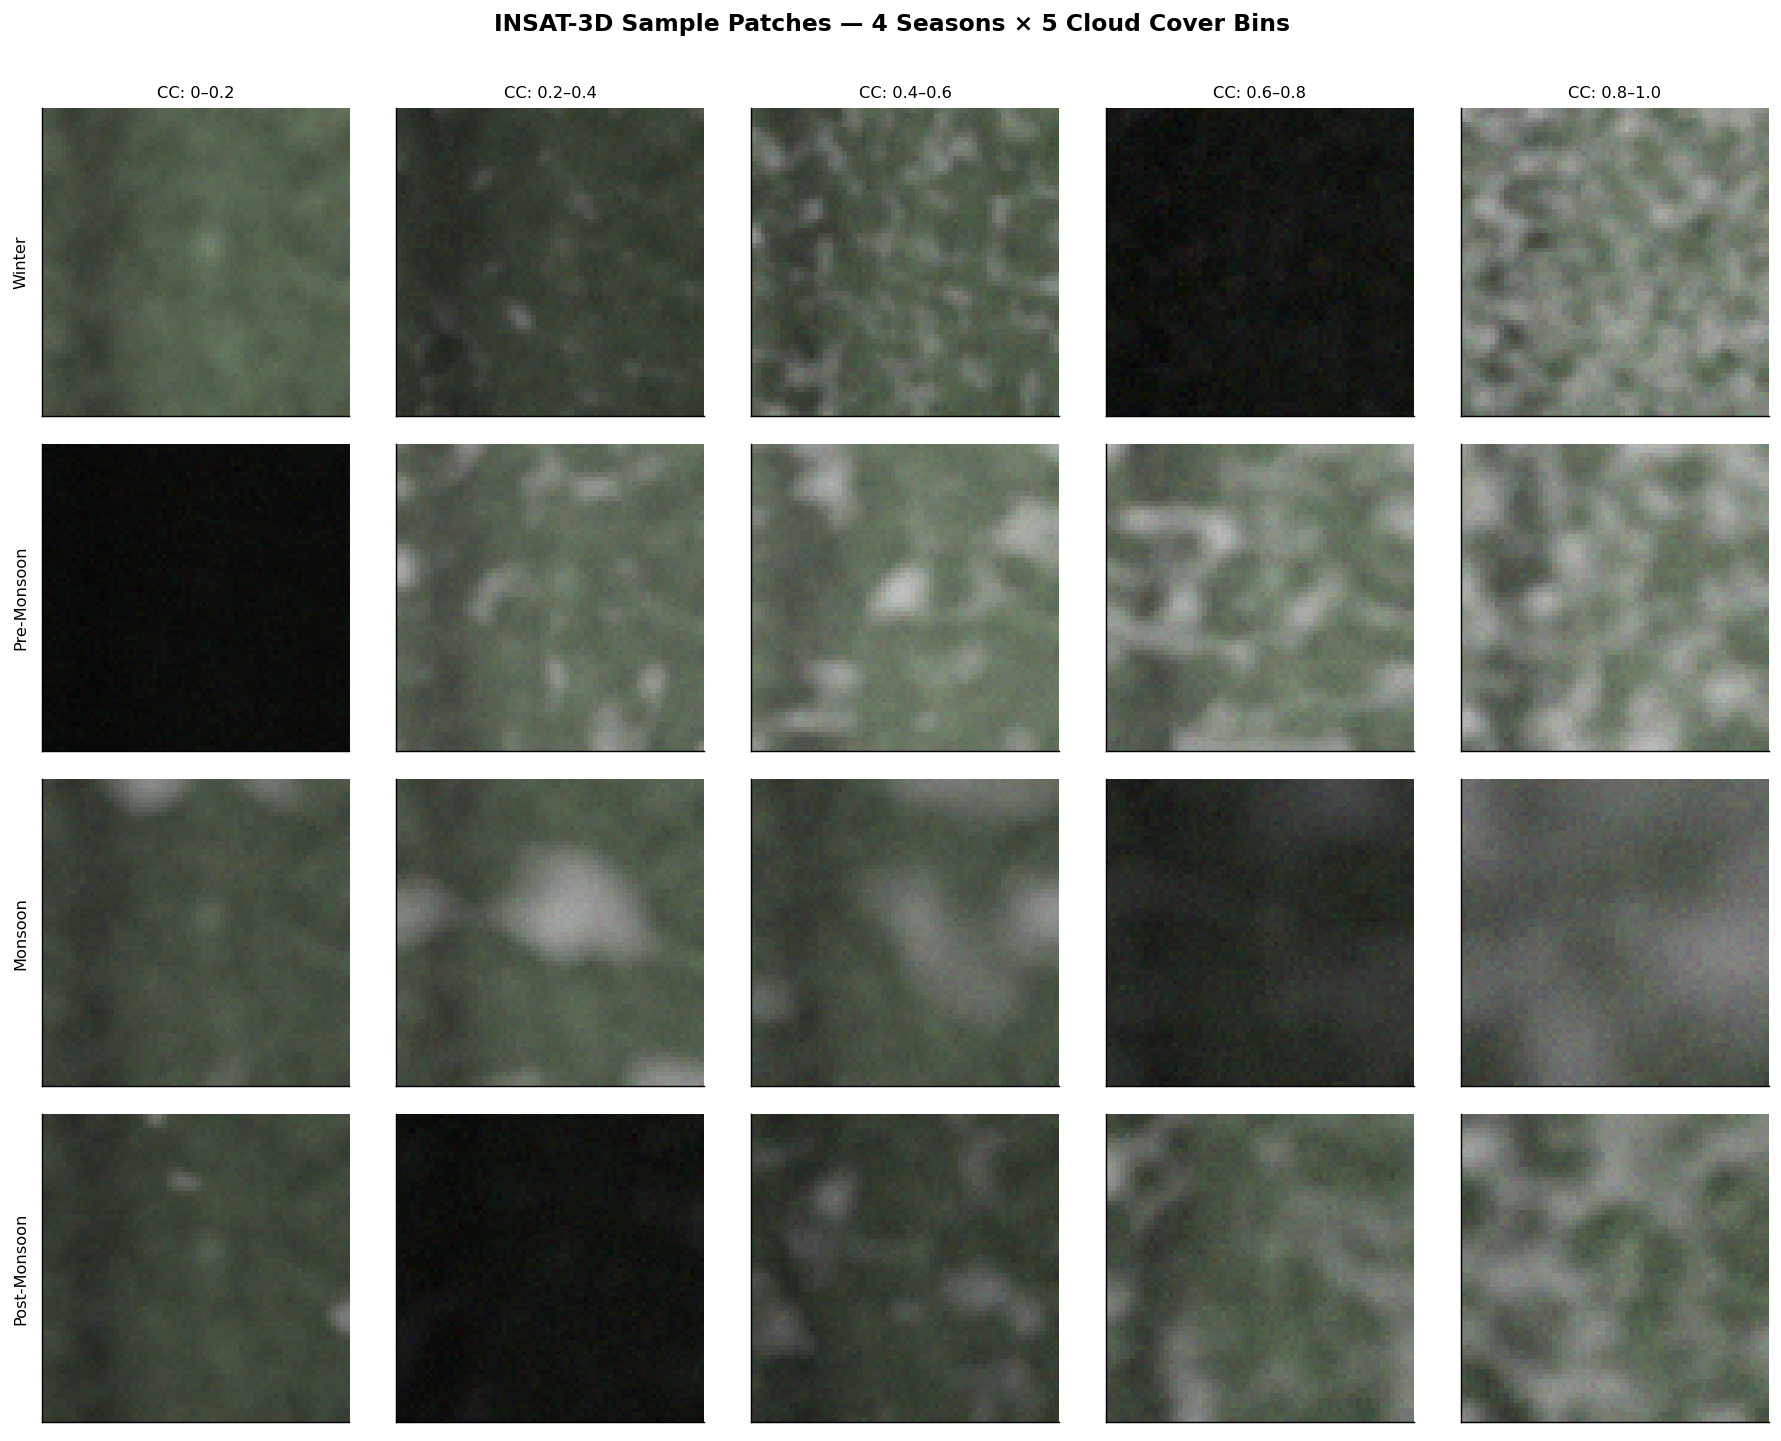

Saved: satellite_sample_grid.png


In [7]:
CC_BINS   = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
CC_LABELS = ['0–0.2', '0.2–0.4', '0.4–0.6', '0.6–0.8', '0.8–1.0']
SEASONS   = ['Winter', 'Pre-Monsoon', 'Monsoon', 'Post-Monsoon']

# Only use daytime patches for visual quality
df['idx'] = df.index
day_df = df[df['hour'].between(7, 17)].copy()
day_df['cc_bin'] = pd.cut(day_df['cloud_cover'], bins=CC_BINS, labels=CC_LABELS, include_lowest=True)

np.random.seed(12)
fig, axes = plt.subplots(4, 5, figsize=(14, 11))
fig.suptitle('INSAT-3D Sample Patches — 4 Seasons × 5 Cloud Cover Bins',
             fontsize=13, fontweight='bold', y=1.005)

for row, season in enumerate(SEASONS):
    for col, cc_lbl in enumerate(CC_LABELS):
        ax = axes[row, col]
        sub = day_df[(day_df['season'] == season) & (day_df['cc_bin'] == cc_lbl)]
        if len(sub) > 0:
            chosen = sub.sample(1, random_state=row*5+col)['idx'].values[0]
            patch  = images[chosen]
            # Normalize for display if needed
            if patch.max() <= 1.0:
                disp = (patch * 255).astype(np.uint8)
            else:
                disp = patch.astype(np.uint8)
            ax.imshow(disp)
        else:
            ax.set_facecolor('#EEEEEE')
            ax.text(0.5, 0.5, 'N/A', ha='center', va='center',
                    transform=ax.transAxes, color='gray')
        ax.set_xticks([])
        ax.set_yticks([])
        if row == 0:
            ax.set_title(f'CC: {cc_lbl}', fontsize=9)
        if col == 0:
            ax.set_ylabel(season, fontsize=9, rotation=90, labelpad=4)

plt.tight_layout()
fig.savefig(FIG / 'satellite_sample_grid.png', bbox_inches='tight')
plt.show()
print('Saved: satellite_sample_grid.png')

## 5. RGB Channel Distributions by Season

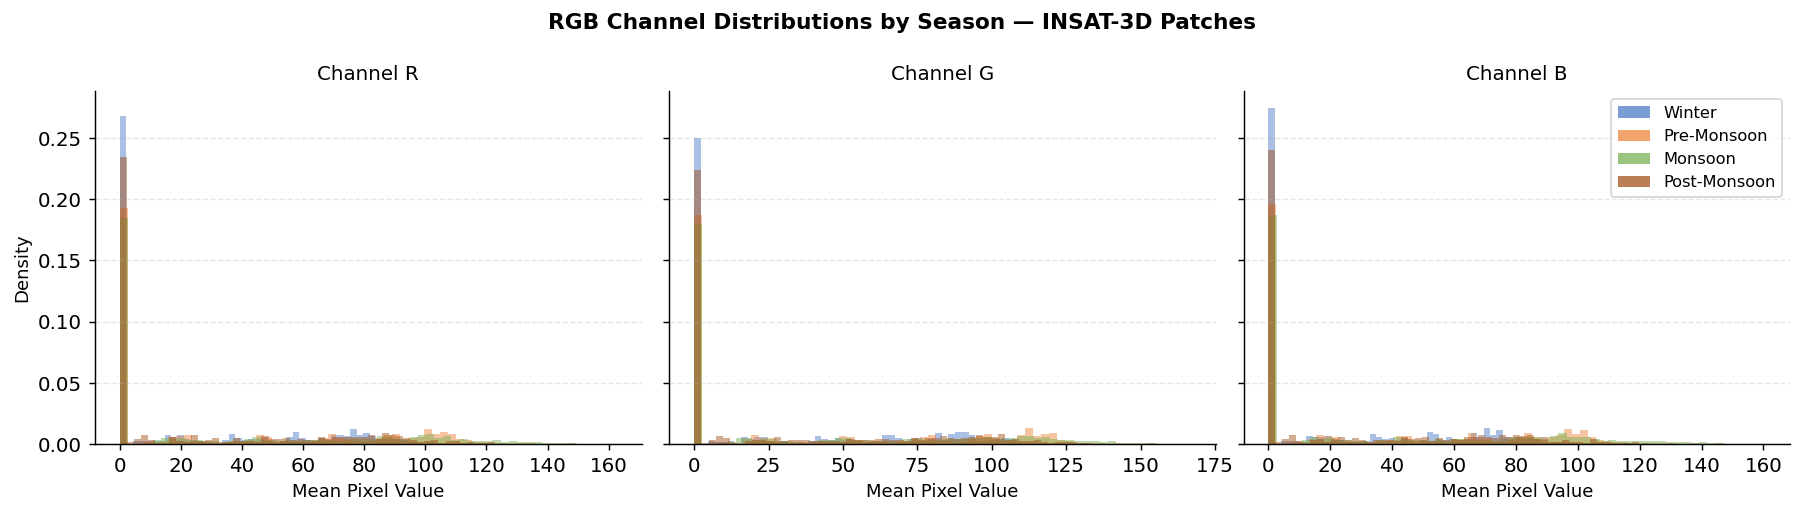

Saved: satellite_rgb_distributions.png


In [8]:
# Compute per-patch per-channel mean
ch_means = images.mean(axis=(1, 2))   # (8760, 3)
df['R_mean'] = ch_means[:, 0]
df['G_mean'] = ch_means[:, 1]
df['B_mean'] = ch_means[:, 2]

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
fig.suptitle('RGB Channel Distributions by Season — INSAT-3D Patches',
             fontsize=12, fontweight='bold')

CH_INFO = [('R_mean', 'R', '#D62728'), ('G_mean', 'G', '#2CA02C'), ('B_mean', 'B', '#1F77B4')]

for ax, (ch, ch_label, clr_ch) in zip(axes, CH_INFO):
    for season, clr in SEASON_CLR.items():
        vals = df[df['season'] == season][ch]
        ax.hist(vals, bins=60, alpha=0.45, color=clr, label=season,
                density=True, edgecolor='none')
    ax.set_title(f'Channel {ch_label}', fontsize=11)
    ax.set_xlabel('Mean Pixel Value', fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

axes[0].set_ylabel('Density', fontsize=10)
handles = [mpatches.Patch(facecolor=c, alpha=0.7, label=s) for s, c in SEASON_CLR.items()]
axes[-1].legend(handles=handles, fontsize=9)

plt.tight_layout()
fig.savefig(FIG / 'satellite_rgb_distributions.png', bbox_inches='tight')
plt.show()
print('Saved: satellite_rgb_distributions.png')

## 6. Export Satellite Patches as PNG Files

Save each patch as an individual PNG organised by `YYYY/MM/YYYYmmddTHHMMSS.png` for downstream tooling.

In [9]:
img_dir = DATA / 'satellite_images'
img_dir.mkdir(exist_ok=True)

ts_series = scada['timestamp']

for i, (ts, patch) in enumerate(zip(ts_series, images)):
    subdir = img_dir / ts.strftime('%Y/%m')
    subdir.mkdir(parents=True, exist_ok=True)
    fname = ts.strftime('%Y%m%dT%H%M%S') + '.png'
    # Convert float [0,1] to uint8 if needed
    if patch.max() <= 1.0:
        arr = (patch * 255).clip(0, 255).astype(np.uint8)
    else:
        arr = patch.clip(0, 255).astype(np.uint8)
    Image.fromarray(arr).save(subdir / fname)
    if (i + 1) % 1000 == 0:
        print(f'  {i+1}/8760 images saved')

print(f'Done. Images saved to {img_dir}')

  1000/8760 images saved
  2000/8760 images saved
  3000/8760 images saved
  4000/8760 images saved
  5000/8760 images saved
  6000/8760 images saved
  7000/8760 images saved
  8000/8760 images saved
Done. Images saved to ../solar_forecast/data/satellite_images
